## Injection Molding Dataset – EDA

**Understand the dataset structure, identify individual defect labels, analyze missing values, study material types (PP vs ABS), investigate defect distributions, and prepare insights for multi-label defect prediction modeling.**

**Imports**
- The required libraries are imported for data loading, preprocessing, visualization, and exploratory data analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Dataset Loading**
- The dataset is loaded from a Parquet file. The first few rows are displayed to understand the structure and available features.

In [2]:
df = pd.read_parquet("dataset.parquet")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (564, 334)


,MET_MachineCycleID,MET_JobCycleID,MET_Timestamp,MET_MaterialName,MET_ExperimentNumber,MET_MaterialMoisture,LBL_NOK,LBL_OldGranulate,LBL_SinkMarks,LBL_SprueCircle,...,TCN_ActualProcessPower,TCN_ActualPumpPower,TCN_ActualPumpSpeed,TCN_ActualPumpSpeedRPM,TCN_ActualTemperatureDifference,TCN_PressureMainLine,TCN_PressureReturnLine,TCN_SetTemperature,TCN_TemperatureMainLine,TCN_TemperatureReturnLine
0,18535,1,2021-12-07 08:27:34,PP,A16,0.047,1,0.0,1,0,...,"[0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, ...","[0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, ...","[100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100...","[2950.0, 2950.0, 2950.0, 2950.0, 2950.0, 2950....","[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, ...","[2.6, 2.6, 2.6, 2.6, 2.6, 2.6, 2.6, 2.6, 2.6, ...","[2.7, 2.7, 2.7, 2.7, 2.7, 2.7, 2.7, 2.7, 2.7, ...","[20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20....","[19.8, 19.8, 19.8, 19.8, 19.8, 19.8, 19.8, 19....","[20.3, 20.3, 20.3, 20.3, 20.3, 20.3, 20.3, 20...."
1,18536,2,2021-12-07 08:28:31,PP,A16,0.047,1,0.0,1,0,...,"[0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, ...","[0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, ...","[100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100...","[2950.0, 2950.0, 2950.0, 2950.0, 2950.0, 2950....","[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, ...","[2.6, 2.6, 2.6, 2.6, 2.6, 2.6, 2.6, 2.6, 2.6, ...","[2.7, 2.7, 2.7, 2.7, 2.7, 2.7, 2.7, 2.7, 2.7, ...","[20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20....","[19.8, 19.8, 19.8, 19.8, 19.8, 19.8, 19.8, 19....","[20.3, 20.3, 20.3, 20.3, 20.3, 20.3, 20.3, 20...."
2,18537,3,2021-12-07 08:29:28,PP,A16,0.047,1,0.0,1,0,...,"[0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, ...","[0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, ...","[100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100...","[2950.0, 2950.0, 2950.0, 2950.0, 2950.0, 2950....","[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, ...","[2.6, 2.6, 2.6, 2.6, 2.6, 2.6, 2.6, 2.6, 2.6, ...","[2.7, 2.7, 2.7, 2.7, 2.7, 2.7, 2.7, 2.7, 2.7, ...","[20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20....","[19.8, 19.8, 19.8, 19.8, 19.8, 19.8, 19.8, 19....","[20.3, 20.3, 20.3, 20.3, 20.3, 20.3, 20.3, 20...."
3,18538,4,2021-12-07 08:30:25,PP,A16,0.047,1,0.0,1,0,...,"[0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, ...","[0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, ...","[100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100...","[2950.0, 2950.0, 2950.0, 2950.0, 2950.0, 2950....","[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, ...","[2.6, 2.6, 2.6, 2.6, 2.6, 2.6, 2.6, 2.6, 2.6, ...","[2.7, 2.7, 2.7, 2.7, 2.7, 2.7, 2.7, 2.7, 2.7, ...","[20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20....","[19.8, 19.8, 19.8, 19.8, 19.8, 19.8, 19.8, 19....","[20.3, 20.3, 20.3, 20.3, 20.3, 20.3, 20.3, 20...."
4,18539,5,2021-12-07 08:31:22,PP,A16,0.047,1,0.0,1,0,...,"[0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, ...","[0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, ...","[100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100...","[2950.0, 2950.0, 2950.0, 2950.0, 2950.0, 2950....","[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, ...","[2.7, 2.7, 2.7, 2.7, 2.7, 2.7, 2.7, 2.7, 2.7, ...","[2.7, 2.7, 2.7, 2.7, 2.7, 2.7, 2.7, 2.7, 2.7, ...","[20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20....","[19.8, 19.8, 19.8, 19.8, 19.8, 19.8, 19.8, 19....","[20.3, 20.3, 20.3, 20.3, 20.3, 20.3, 20.3, 20...."


**Dataset Structure**

This step provides:
- Number of rows and columns
- Data types
- Missing values
- Memory usage

This helps identify numerical, categorical, datetime, and time-series features.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 564 entries, 0 to 563
Columns: 334 entries, MET_MachineCycleID to TCN_TemperatureReturnLine
dtypes: datetime64[us](1), float64(162), int32(2), int64(17), object(152)
memory usage: 1.4+ MB


**Missing Values**

Missing values are examined to determine:
- Which features contain null values
- The extent of missing data
- Whether imputation or removal will be required later

In [33]:
missing = df.isnull().sum()
missing = missing[missing > 0]

# Display the top 30 columns with the most missing values
display(missing.sort_values(ascending=False).head(30))

# Total number of columns containing missing values
print("Number of columns with missing values:", len(missing))

CV_Image4Name                              408
CV_Width                                   408
DRY_acTotalWeight                          408
DRY_acRegCircuitInletTemp                  408
DRY_acDryCircuitDewPoint                   408
DRY_acComp1TotalWeight                     408
DXP_InjPrs1Act_InjectionPhaseArea          408
DXP_InjPrs1Act_RelevantHoldingPhaseArea    408
DXP_InjPrs1Act_FullHoldingPhaseArea        408
DRY_acWeight                               408
DRY_acBatchCounter                         408
DRY_acComp1DosRate                         408
SET_CoolingTime                            408
SET_BackPressure                           408
SET_HoldingTime                            408
SET_InjectionSpeed                         408
SIM_TempVerRng                             360
SIM_TempVerStd                             360
SIM_TempGradVerStd                         360
SIM_TempGradVerRng                         360
SIM_TempGradHorStd                         360
SIM_TempGradH

Number of columns with missing values: 118


In [34]:
# Percentage of missing values in each column
missing_percent = (df.isnull().mean() * 100).round(2)
missing_percent = missing_percent[missing_percent > 0]

display(missing_percent.sort_values(ascending=False).head(30))

CV_Image4Name                              72.34
CV_Width                                   72.34
DRY_acTotalWeight                          72.34
DRY_acRegCircuitInletTemp                  72.34
DRY_acDryCircuitDewPoint                   72.34
DRY_acComp1TotalWeight                     72.34
DXP_InjPrs1Act_InjectionPhaseArea          72.34
DXP_InjPrs1Act_RelevantHoldingPhaseArea    72.34
DXP_InjPrs1Act_FullHoldingPhaseArea        72.34
DRY_acWeight                               72.34
DRY_acBatchCounter                         72.34
DRY_acComp1DosRate                         72.34
SET_CoolingTime                            72.34
SET_BackPressure                           72.34
SET_HoldingTime                            72.34
SET_InjectionSpeed                         72.34
SIM_TempVerRng                             63.83
SIM_TempVerStd                             63.83
SIM_TempGradVerStd                         63.83
SIM_TempGradVerRng                         63.83
SIM_TempGradHorStd  

**Defect Distribution**

The dataset contains multiple defect labels representing different failure types. Before building a model, it is important to understand how frequently each defect occurs.
- 0 = Defect absent
- 1 = Defect present

The class distribution helps determine whether the dataset is balanced or imbalanced.

In [5]:
label_cols = [c for c in df.columns if c.startswith("LBL")]

label_cols

['LBL_NOK',
 'LBL_OldGranulate',
 'LBL_SinkMarks',
 'LBL_SprueCircle',
 'LBL_StreaksLevel1',
 'LBL_StreaksLevel2',
 'LBL_StreaksLevel3',
 'LBL_Underfilled']

In [6]:
defect_labels = [
    "LBL_OldGranulate",
    "LBL_SinkMarks",
    "LBL_SprueCircle",
    "LBL_StreaksLevel1",
    "LBL_StreaksLevel2",
    "LBL_StreaksLevel3",
    "LBL_Underfilled"
]

defect_labels

['LBL_OldGranulate',
 'LBL_SinkMarks',
 'LBL_SprueCircle',
 'LBL_StreaksLevel1',
 'LBL_StreaksLevel2',
 'LBL_StreaksLevel3',
 'LBL_Underfilled']

In [7]:
defect_counts = df[defect_labels].sum().sort_values(ascending=False)

print(defect_counts)

LBL_SinkMarks        143.0
LBL_SprueCircle       72.0
LBL_Underfilled       60.0
LBL_StreaksLevel3     48.0
LBL_StreaksLevel1     30.0
LBL_StreaksLevel2     18.0
LBL_OldGranulate       9.0
dtype: float64


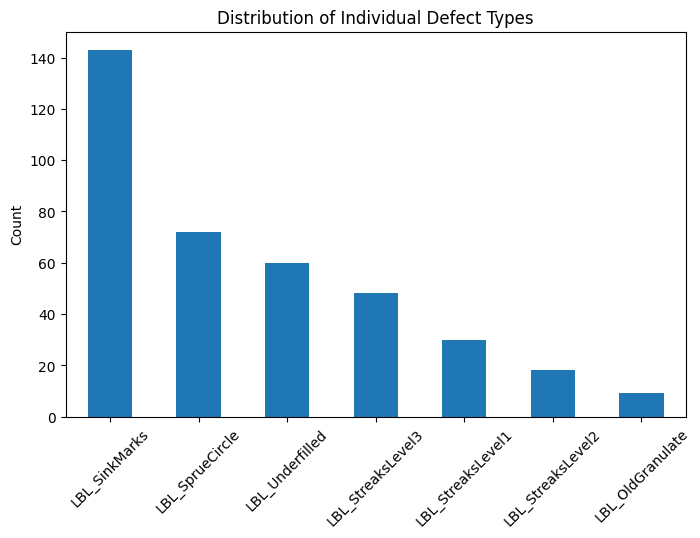

In [8]:
plt.figure(figsize=(8,5))

defect_counts.plot(kind="bar")

plt.title("Distribution of Individual Defect Types")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

**Observations from the Defect Distribution Graph**

- Sink Marks is the most frequent defect.
- Sprue Circle and Underfilled defects occur at a moderate level.
- Streaks Level 1, Level 2, and Level 3 occur less frequently.
- Old Granulate is the least frequent defect.
- The defect labels are imbalanced, so this should be considered during model training.

In [9]:
quality_cols = [
    "CV_Warpage",
    "SCA_PartWeight"
]

df[quality_cols].describe()

,CV_Warpage,SCA_PartWeight
count,564.000000,564.000000
mean,0.907500,99.717872
std,0.597664,9.149226
min,0.050000,86.230000
25%,0.470000,92.037500
50%,0.815000,96.055000
75%,1.257500,110.802500
max,7.100000,112.780000


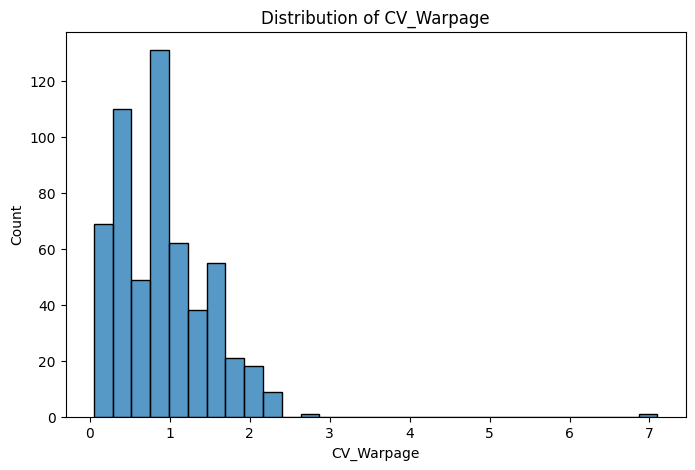

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(df["CV_Warpage"], bins=30)

plt.title("Distribution of CV_Warpage")
plt.show()

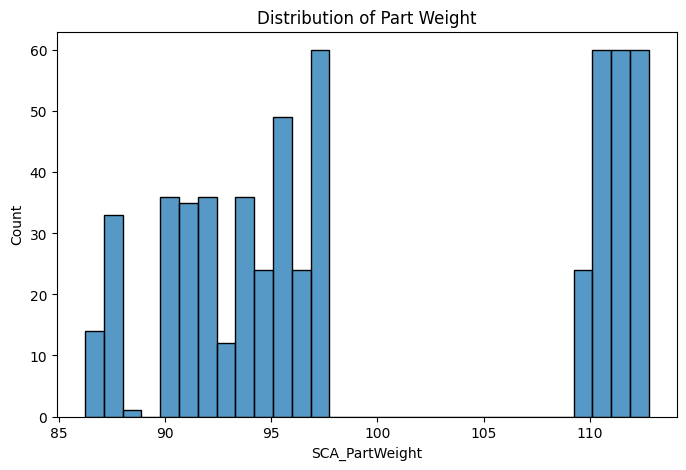

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df["SCA_PartWeight"], bins=30)

plt.title("Distribution of Part Weight")
plt.show()

**Material Distribution**

The dataset contains different material types such as:
- PP (Polypropylene)
- ABS (Acrylonitrile Butadiene Styrene)

Material properties may influence the occurrence of different defect types.

In [12]:
df["MET_MaterialName"].value_counts()

MET_MaterialName
PP     360
ABS    204
Name: count, dtype: int64

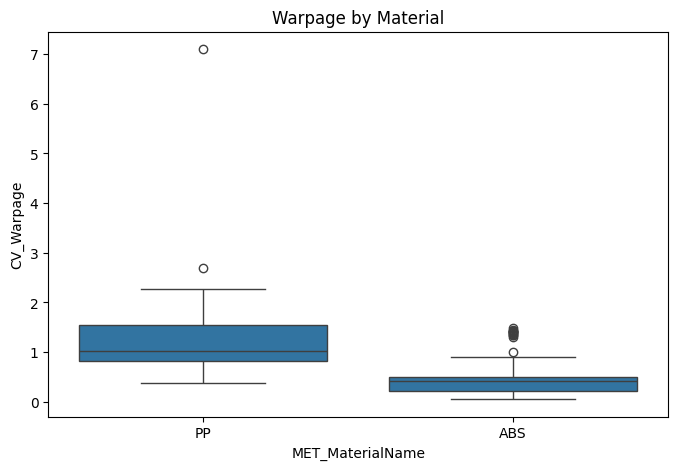

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="MET_MaterialName",
    y="CV_Warpage"
)

plt.title("Warpage by Material")
plt.show()

**Defect Distribution by Material**

- This analysis compares the occurrence of each defect type across the different material types (PP and ABS). It helps identify whether certain materials are associated with specific manufacturing defects.

In [14]:
material_defects = df.groupby("MET_MaterialName")[defect_labels].sum()

material_defects

,LBL_OldGranulate,LBL_SinkMarks,LBL_SprueCircle,LBL_StreaksLevel1,LBL_StreaksLevel2,LBL_StreaksLevel3,LBL_Underfilled
MET_MaterialName,,,,,,,
ABS,0.0,48,0,30,18,48,0
PP,9.0,95,72,0,0,0,60


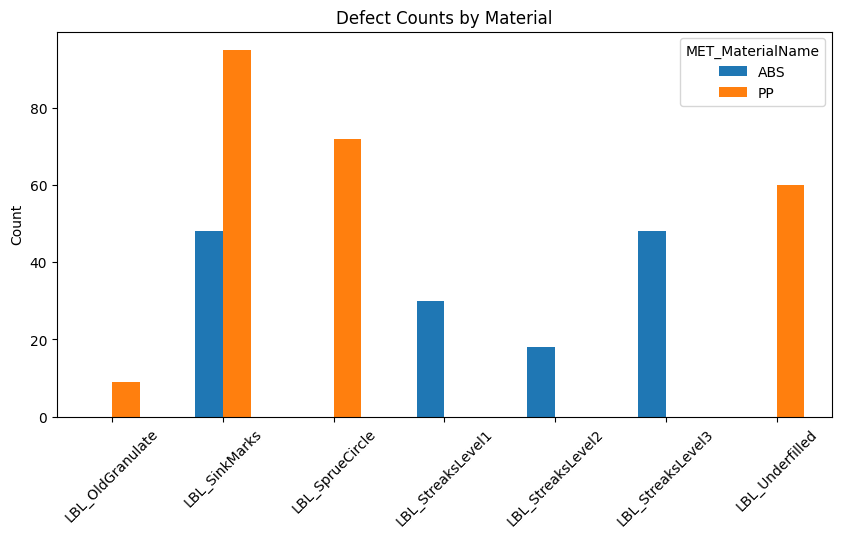

In [15]:
material_defects.T.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Defect Counts by Material")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

**Observation**

- PP material shows a higher number of Sink Marks, Sprue Circle, Underfilled, and Old Granulate defects.
- ABS material mainly exhibits Streaks Level 1, Level 2, and Level 3 defects.
- This suggests that material type may influence the occurrence of specific defect types.

In [16]:
num_df = df.select_dtypes(include="number")

print(num_df.shape)

(564, 181)


In [17]:
num_df.columns.tolist()[:50]

['MET_MachineCycleID',
 'MET_JobCycleID',
 'MET_MaterialMoisture',
 'LBL_NOK',
 'LBL_OldGranulate',
 'LBL_SinkMarks',
 'LBL_SprueCircle',
 'LBL_StreaksLevel1',
 'LBL_StreaksLevel2',
 'LBL_StreaksLevel3',
 'LBL_Underfilled',
 'CV_Diameter3',
 'CV_Height1',
 'CV_Height2',
 'CV_Height2Small',
 'CV_Height3',
 'CV_Warpage',
 'CV_Width',
 'CV_Width1',
 'CV_Width2',
 'CV_Width2Small',
 'CV_Width3',
 'DXP_InjPrs1Act_FullHoldingPhaseArea',
 'DXP_InjPrs1Act_InjectionPhaseArea',
 'DXP_InjPrs1Act_RelevantHoldingPhaseArea',
 'E77_AreaCavityPressure1Dr1',
 'E77_AreaCavityPressure1Max',
 'E77_AreaInjectionSpeed',
 'E77_AreaInjectionSpeedMax',
 'E77_AreaInjectionStroke',
 'E77_AreaMeltPressure',
 'E77_AreaMeltPressureMax',
 'E77_AreaPower',
 'E77_AreaPowerMax',
 'E77_BackPressureMax',
 'E77_CavityPressure1Max',
 'E77_CoolingTime',
 'E77_CushionVolume',
 'E77_CycleTime',
 'E77_CylinderTemperature01',
 'E77_CylinderTemperature02',
 'E77_CylinderTemperature03',
 'E77_CylinderTemperature04',
 'E77_Cylinde

**Correlation Analysis**

Correlation is used to identify relationships between process parameters and quality metrics.

Strong positive or negative correlations may indicate important predictors for modeling.

In [18]:
corr = num_df.corr()

corr["CV_Warpage"].sort_values(ascending=False).head(20)

CV_Warpage                   1.000000
E77_PlastificationSpeed      0.630345
E77_MeltPressure2Max         0.564475
IR_Img1TempGradHorStd        0.536051
IR_Img1TempGradHorStdDiff    0.531024
ENV_AirHumidity              0.525612
IR_Img3TempGradVerStd        0.516950
IR_Img1TempGradHorRng        0.516008
IR_Img1TempGradHorRngDiff    0.511877
IR_Img2TempGradHorStdDiff    0.501534
IR_Img2TempGradHorStd        0.501423
IR_Img3TempGradVerRng        0.490096
IR_Img2TempGradVerStd        0.481358
IR_Img2TempGradHorRng        0.477082
IR_Img2TempGradHorRngDiff    0.474064
SIM_FlowRateMax              0.472887
E77_TransferStroke           0.440997
IR_Img2TempGradVerStdDiff    0.413709
IR_Img2TempGradVerRng        0.413313
CV_Diameter3                 0.408265
Name: CV_Warpage, dtype: float64

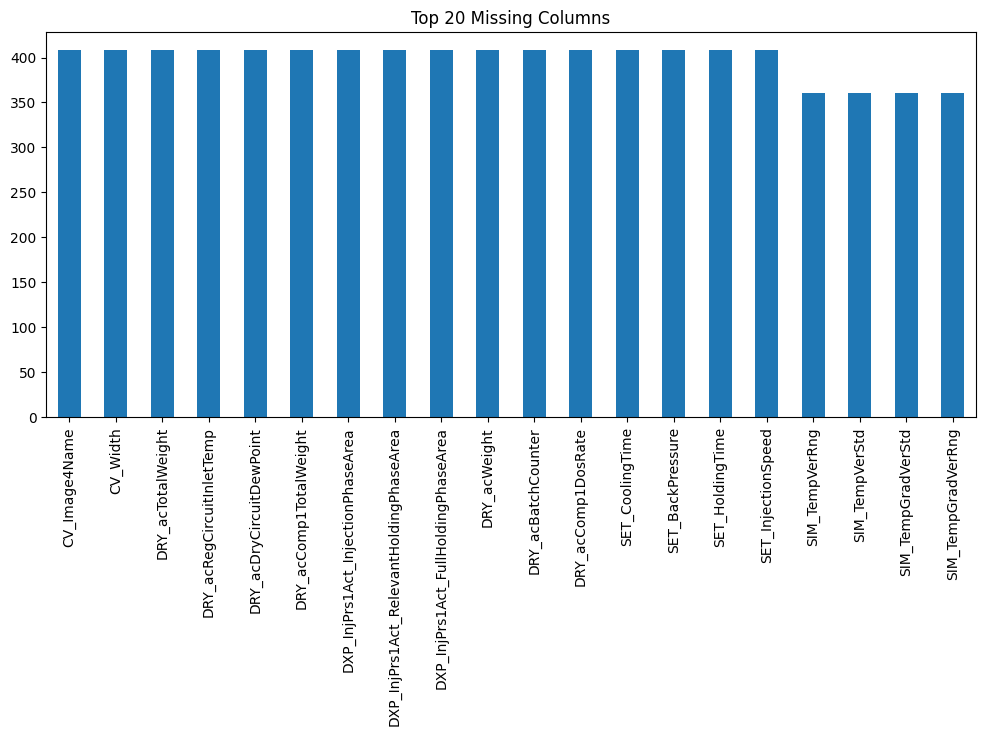

In [19]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False).head(20).plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Top 20 Missing Columns")
plt.show()

**Overall Product Quality (OK/NOK)**

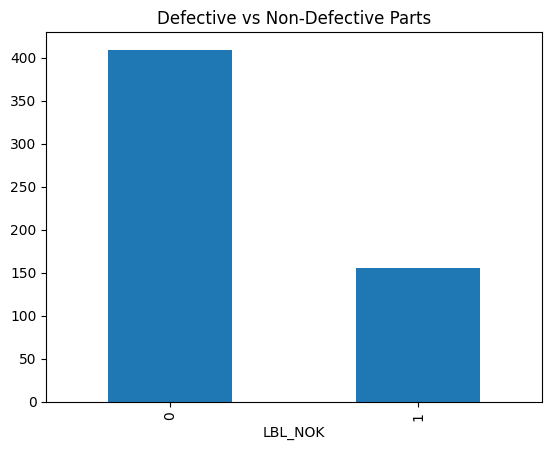

In [20]:
df["LBL_NOK"].value_counts().plot(
    kind="bar"
)

plt.title("Defective vs Non-Defective Parts")
plt.show()

**Multi-Label Analysis**

In [21]:
df["Number_of_Defects"] = df[defect_labels].sum(axis=1)

df["Number_of_Defects"].value_counts().sort_index()

Number_of_Defects
0.0    258
1.0    244
2.0     50
3.0     12
Name: count, dtype: int64

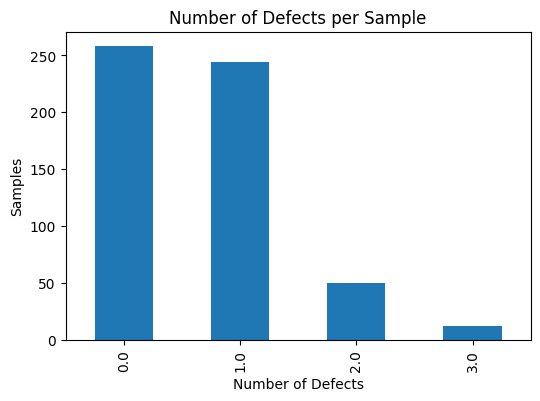

In [22]:
plt.figure(figsize=(6,4))

df["Number_of_Defects"].value_counts().sort_index().plot(kind="bar")

plt.title("Number of Defects per Sample")

plt.xlabel("Number of Defects")

plt.ylabel("Samples")

plt.show()

**Observations**
- Most production cycles contain either no defects or a single defect.
- A smaller number of samples contain two or three defects.
- This confirms that multiple defects can occur in one production cycle, supporting a multi-label prediction approach.

**Defect Co-occurrence**

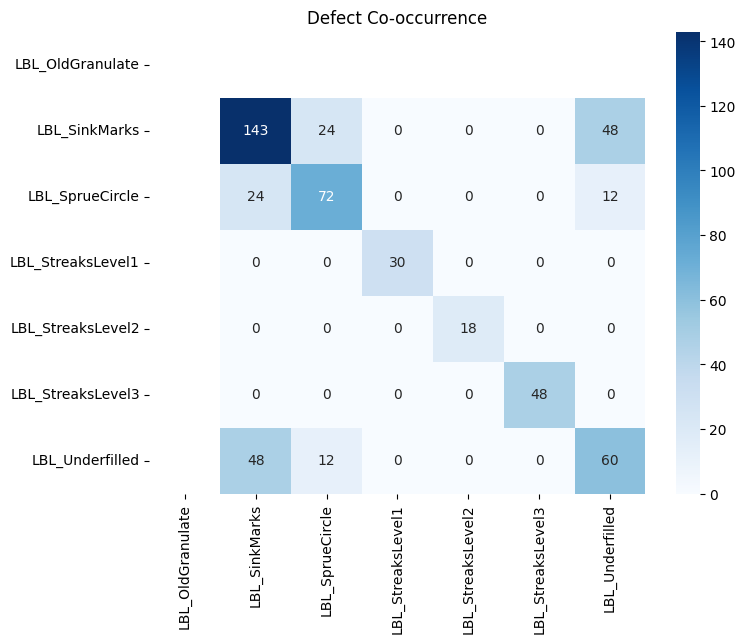

In [23]:
co_occurrence = df[defect_labels].T.dot(df[defect_labels])

plt.figure(figsize=(8,6))

sns.heatmap(
    co_occurrence,
    annot=True,
    cmap="Blues",
    fmt="g"
)

plt.title("Defect Co-occurrence")

plt.show()

**Observations**
- Sink Marks frequently occur together with Underfilled defects.
- Sink Marks and Sprue Circle also show some co-occurrence.
- Several defect pairs do not occur together, indicating that some defects are independent of each other.

In [24]:
exp_warp = (
    df.groupby("MET_ExperimentNumber")
      ["CV_Warpage"]
      .mean()
      .sort_values()
)

exp_warp

MET_ExperimentNumber
A08    0.365417
A05    0.441667
A07    0.442917
A16    0.453043
Z01    0.520417
A15    0.522000
A12    0.621250
A13    0.624583
A09    0.678333
A11    0.692917
A03    0.701667
A02    0.718750
A01    0.724167
A04    0.735417
A24    0.737500
A30    0.990833
A23    1.043333
A31    1.045833
A10    1.053333
A06    1.072083
A22    1.136667
A21    1.399167
A27    1.425000
A20    1.489167
A14    1.543333
A32    1.570000
A26    1.646667
A29    1.895000
A28    2.185833
A25    2.259167
Name: CV_Warpage, dtype: float64

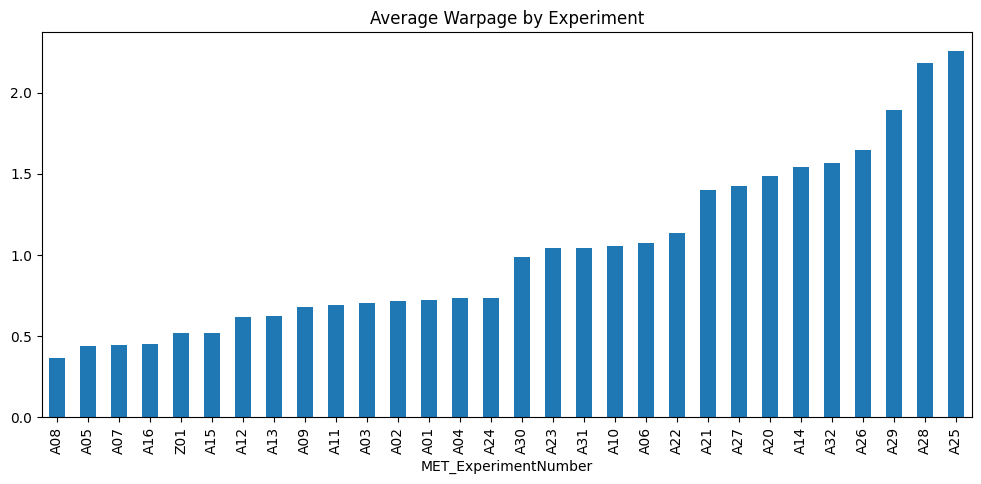

In [25]:
plt.figure(figsize=(12,5))

exp_warp.plot(kind="bar")

plt.title("Average Warpage by Experiment")
plt.show()

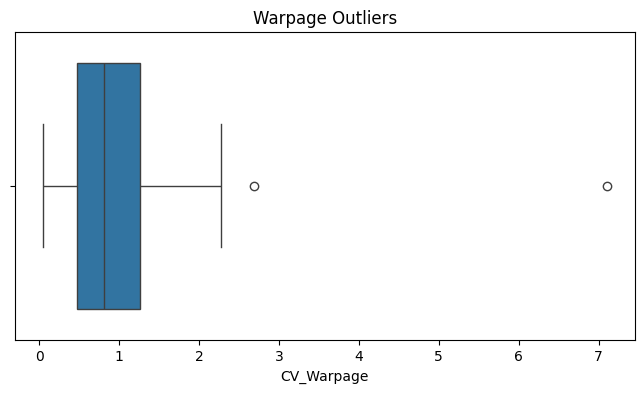

In [26]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df["CV_Warpage"]
)

plt.title("Warpage Outliers")
plt.show()

In [27]:
pd.crosstab(
    df["MET_MaterialName"],
    df["LBL_NOK"]
)

LBL_NOK,0,1
MET_MaterialName,,
ABS,156,48
PP,253,107


In [28]:
corr["CV_Warpage"].sort_values().head(20)

CV_Width1                        -0.759879
CV_Height1                       -0.744070
CV_Height2                       -0.701838
MET_MaterialMoisture             -0.650734
SET_HoldingPressure2             -0.618806
E77_TransferSpecificPressure1    -0.574081
SCA_PartWeight                   -0.573769
MET_MachineCycleID               -0.572371
E77_TransferPressure             -0.563772
E77_HoldingPressureMax           -0.563611
E77_AreaMeltPressure             -0.551751
SIM_InjectionPressureArea        -0.524126
E77_InjectionUnitForwardsTime    -0.521685
E77_InjectionUnitBackwardsTime   -0.497219
E77_CycleTime                    -0.481693
E77_AreaMeltPressureMax          -0.474536
E77_InjectionPressureMax         -0.473798
SET_HoldingPressure1             -0.473528
CV_Width2                        -0.459062
E77_CavityPressure1Max           -0.452239
Name: CV_Warpage, dtype: float64

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 564 entries, 0 to 563
Columns: 335 entries, MET_MachineCycleID to Number_of_Defects
dtypes: datetime64[us](1), float64(163), int32(2), int64(17), object(152)
memory usage: 1.4+ MB


# EDA Summary & Key Findings

**Dataset Overview**
- Dataset contains 564 observations and 334 features.
- Features include numerical, categorical, datetime, and time-series data.
- 152 columns are stored as object data types, with many containing time-series sensor measurements.

**Quality Targets**
- The dataset contains several defect labels:
  - LBL_SinkMarks
  - LBL_SprueCircle
  - LBL_StreaksLevel1
  - LBL_StreaksLevel2
  - LBL_StreaksLevel3
  - LBL_Underfilled
  - LBL_OldGranulate
- Additionally, LBL_NOK indicates the overall quality status of a part (OK/NOK) and is treated separately from the individual defect labels.

**Missing Values**
- Missing values were identified in 118 columns of the dataset. These missing values will require appropriate preprocessing, such as imputation or removal, before model training.

**Material Analysis**
- Dataset contains both PP and ABS materials.
- Material type appears to influence the occurrence of several defect types, indicating that material selection may be an important predictor during model development.

**Correlation Analysis**
- Correlation analysis identified relationships among numerical process variables. These relationships can assist feature selection during model development for defect classification.
- Correlation results can guide feature selection during modeling.

**Time-Series Features**
- Many process variables (DOS, DRY, TCN, etc.) are stored as NumPy arrays.
- These represent machine sensor measurements collected during the molding cycle.
- Additional feature extraction will be required before modeling.

**Recommendations**
- Perform preprocessing and feature engineering.
- Extract statistical features from time-series columns.
- Train classification models for multi-label defect prediction after feature engineering and preprocessing.

**Conclusion**

The exploratory data analysis provided a comprehensive understanding of the injection molding dataset by examining its structure, data quality, missing values, feature distributions, defect label frequencies, material types, numerical correlations, and time-series characteristics. The analysis showed that missing values are present in several columns and will require preprocessing before model development. Material type appears to influence the occurrence of several defect types, while correlation analysis identified relationships among numerical process variables that may assist feature selection. Furthermore, the presence of time-series sensor data indicates that feature extraction or specialized sequence-based models will be beneficial. Overall, the EDA established a strong foundation for building machine learning classification models capable of predicting multiple injection molding defects.